In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_excel("Weight of copper dataset.xlsx")
df.head()

,Unnamed: 0,power_rating,weight_of_copper,category
0,0,16.46,34.69,high
1,1,12.52,28.78,high
2,2,7.66,21.48,high
3,3,21.09,41.64,high
4,4,24.43,46.64,high


In [15]:
df = df.drop("Unnamed: 0",axis = 1)
df.head()

,power_rating,weight_of_copper,category
0,16.46,34.69,high
1,12.52,28.78,high
2,7.66,21.48,high
3,21.09,41.64,high
4,24.43,46.64,high


In [20]:
k = {'low' : 0,'high' : 1}
df['category'] = df['category'].map(k)
x = df[["power_rating","weight_of_copper"]]
y = df[['category']]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.33,random_state = 42)
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth = 2,random_state = 0)
clf.fit(x_train,y_train.values.ravel())

,n_estimators,100
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred = clf.predict(x_test)
y_pred

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [22]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
print("accuracy score",accuracy_score(y_test,y_pred))
print("mean_squared_error",mean_squared_error(y_test,y_pred))
from sklearn.metrics import confusion_matrix

accuracy score 1.0
mean_squared_error 0.0


In [23]:
y_true = y_test
data = confusion_matrix(y_true,y_pred)
data

array([[  3,   0],
       [  0, 162]])

In [26]:
df_cm = pd.DataFrame(data,columns = np.unique(y_true),index = np.unique(y_true))
df_cm.index.name = "Actual"
df_cm.columns.name = "Predicted"
plt.figure(figsize = (10,7))
sns.set(font_scale = 1.4)
df_cm

Predicted,0,1
Actual,,
0,3,0
1,0,162


<Figure size 1000x700 with 0 Axes>

<Axes: xlabel='Predicted', ylabel='Actual'>

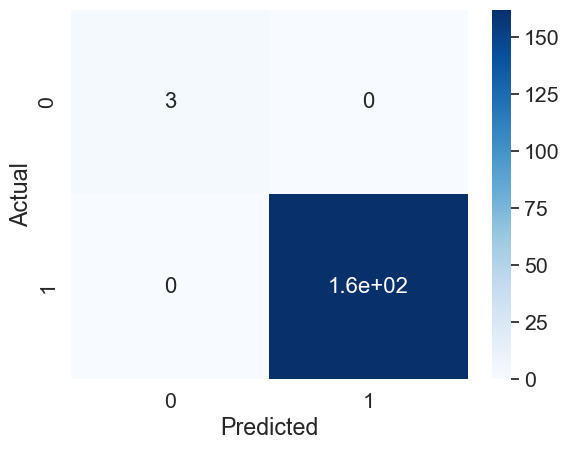

In [27]:
sns.heatmap(df_cm,cmap = "Blues",annot = True,annot_kws = {"size":16})